# Facial Verification with Siamese Networks + Model Evaluation

- References can be found in the Readme.md

In [3]:
#CONFIG
#import sys; print(sys.executable)
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")  # hide TF C++ INFO/WARNING (e.g. benign "OUT_OF_RANGE: End of sequence" at dataset end)
TRAIN = False

## Dependencies setup

Readme.md shows how to setup the envrionment for running this notebook with the correct deps

In [4]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import os, sys, tensorflow as tf

USE_GPU = os.environ.get("USE_GPU", "0") == "1"
gpus = tf.config.list_physical_devices("GPU")

try:
    if USE_GPU and gpus:
        if sys.platform == "darwin":
            tf.config.optimizer.set_experimental_options({"disable_meta_optimizer": True}) #dodge the known slicon Grappler crash
        print(f"GPU enabled ({len(gpus)} device[s])")
    elif USE_GPU and not gpus:
        hint = "pip install tensorflow-metal==1.2.0" if sys.platform == "darwin" else "install the CUDA build of tensorflow"
        print(f"USE_GPU=1 but no GPU visible -> run `{hint}`, then restart the kernel. Using CPU for now.")
    else:
        tf.config.set_visible_devices([], "GPU") # CPU only
        print("CPU mode (USE_GPU=0)")
except RuntimeError as e:                          # set_visible_devices after TF init (cell re-run)
    print("device config already applied, restart kernel to change. (", e, ")")

print("TensorFlow", tf.__version__, "| visible GPUs:", tf.config.get_visible_devices("GPU"))

GPU enabled (1 device[s])
TensorFlow 2.16.2 | visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data Aquisition

In [5]:
POS_PATH = os.path.join('../data', 'positive')
NEG_PATH = os.path.join('../data', 'negative')
ANC_PATH = os.path.join('../data', 'anchor')
VER_PATH = os.path.join('../data', 'verification') # genuine probes for the evaluation

os.makedirs(POS_PATH, exist_ok=True)
os.makedirs(NEG_PATH, exist_ok=True)
os.makedirs(ANC_PATH, exist_ok=True)
os.makedirs(VER_PATH, exist_ok=True)

In [6]:
from pathlib import Path

# Skip extract/copy if negatives already populated
existing = len(list(Path(NEG_PATH).glob("*.jpg")))
if existing > 1000:
    print(f"Negatives already in place ({existing} imgs) - skipping download.")
else:
    import kagglehub, shutil, os, tarfile

    path = kagglehub.dataset_download("atulanandjha/lfwpeople") #https://www.kaggle.com/datasets/atulanandjha/lfwpeople

    # 1. Extract the tgz
    with tarfile.open(f"{path}/lfw-funneled.tgz") as tar:
        tar.extractall(path)
    # 2. Find all jpgs in all subfolders and copy them flatly (shallow)
    for image in Path(path).rglob("*.jpg"):
        shutil.copy2(image, f"{NEG_PATH}/{image.name}")

    print("Data downloaded!")

Negatives already in place (13233 imgs) - skipping download.


## Capture face data with webcam
- performance improved (better than tutrial code) by using just one `cv2.waitKey(1)` check per loop, instead of one check for each key (a, p, q, ESC). This makes the webcam feed more responsive and less laggy.
- added v key to capture held-out verification selfies for evaluation (genuine probes).

In [7]:
import uuid

window_name = 'frame'
cap = cv2.VideoCapture(0)
frame = None

CROP = 400

try:
    if not cap.isOpened():
        raise RuntimeError('Could not open webcam')

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            print('Webcam read failed, stopping capture loop.')
            break

        # center crop
        h, w = frame.shape[:2]
        y0 = max((h - CROP) // 2, 0)
        x0 = max((w - CROP) // 2, 0)
        frame = frame[y0:y0+CROP, x0:x0+CROP, :]

        cv2.imshow(window_name, frame)

        key = cv2.waitKey(1) & 0xFF #just one check makes it react faster without any lag
        # Collect anchors
        if key == ord('a'):
            imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
            cv2.imwrite(imgname, frame)

        # Collect positives
        elif key == ord('p'):
            imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
            cv2.imwrite(imgname, frame)

        # Collect verification images
        elif key == ord('v'):
            imgname = os.path.join(VER_PATH, '{}.jpg'.format(uuid.uuid1()))
            cv2.imwrite(imgname, frame)

        # Exit on q or ESC
        elif key == ord('q') or key == 27:
            break

        # Exit on close of OpenCV window
        if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
            break
except KeyboardInterrupt:
    print('Capture interrupted by user.')
finally:
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

Webcam read failed, stopping capture loop.


## Data Preprocessing

- changed from tutorial: negatives from the lfw are used for training, and they are seeded/deterministic so the exact training negatives are known and reproducible. This allows the evaluation to exclude them from the impostor pool (no leakage).

In [8]:
import random

all_neg_paths = sorted(str(p) for p in Path(NEG_PATH).glob('*.jpg'))
train_neg_paths = random.Random(42).sample(all_neg_paths, min(300, len(all_neg_paths)))

anchor = tf.data.Dataset.list_files(ANC_PATH + '/*.jpg', shuffle=False).take(300)
positive = tf.data.Dataset.list_files(POS_PATH + '/*.jpg', shuffle=False).take(300)
negative = tf.data.Dataset.from_tensor_slices(train_neg_paths)

2026-07-07 19:18:15.622704: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-07-07 19:18:15.622758: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-07-07 19:18:15.622761: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-07-07 19:18:15.622793: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-07 19:18:15.622802: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [9]:
def preprocess(file_path):
    """resize and normalize image"""
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)

    img = tf.image.resize(img, (100,100))
    img = img / 255.0

    return img

# Create a labeled dataset

In [10]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [11]:
samples = data.as_numpy_iterator().next()
print(samples)

(b'../data/anchor/72366a04-7562-11f1-a751-3e4fef0134de.jpg', b'../data/positive/25db9f82-59d1-11f1-ab77-3e4fef0134de.jpg', 1.0)


## Create train and test partitions

In [12]:
def preprocess_twin(input_img, validation_img, label):
    return (preprocess(input_img), preprocess(validation_img), label)

In [13]:
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024, seed=42, reshuffle_each_iteration=False) # reshuffle_each_iteration=False: so test set does not leak into training.

In [14]:
train_data = data.take(round(len(data)*.7))
train_data = train_data.shuffle(buffer_size=1024) # per-epoch reshuffle of training ORDER only (the split above stays fixed)
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

print(f'train_data batches={len(train_data)}  |  test_data batches={len(test_data)}')

train_data batches=16  |  test_data batches=7


## Model Creation

- architecture follows [Koch et al. 2015](https://www.cs.cmu.edu/~rsalakhu/papers/oneshot1.pdf)
- fixed a tutorial slip: `MaxPooling2D(64, (2,2))` set pool_size=64 (the 64 belongs to the Conv2D filters); paper uses 2x2 pooling windows, now `MaxPooling2D((2,2))`.

In [15]:
def make_embedding():
    inp = Input(shape=(100,100,3), name='input_image')

    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D((2,2), padding='same')(c1)

    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D((2,2), padding='same')(c2)

    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D((2,2), padding='same')(c3)

    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)

    return Model(inputs=inp, outputs=d1, name='embedding')

In [16]:
embedding = make_embedding()
embedding.summary(print_fn=print)

Model: "embedding"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼──────────────────────

# Siamese L1 Distance class

In [17]:
class L1Dist(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

# Siamese model

In [18]:
def make_siamese_model():

    input_image = Input(name='input_img', shape=(100,100,3))

    validation_image = Input(name='validation_img', shape=(100,100,3))

    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))

    #break down into one sigmoid value
    classifier = Dense(1, activation='sigmoid')(distances)

    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [19]:
siamese_model = make_siamese_model()
siamese_model.summary(print_fn=print)

Model: "SiameseNetwork"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist (L1Dist)    │ (None, 4096)      │         

## Training
- removed checkpoint callback to speed up training, since the model is small and trains quickly.

In [20]:
loss = tf.losses.BinaryCrossentropy()
opt = tf.optimizers.Adam(0.0001)

In [21]:
@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        x = batch[:2]
        y = batch[2]
        y_pred = siamese_model(x, training=True)
        loss_value = loss(y, y_pred)

    grad = tape.gradient(loss_value, siamese_model.trainable_variables)
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))

    return loss_value

In [22]:
def train(data, EPOCHS):
    for epoch in range(1, EPOCHS+1):
        print(f'Epoch {epoch}/{EPOCHS}')
        progbar = tf.keras.utils.Progbar(len(data))
        for idx, batch in enumerate(data.as_numpy_iterator()):
            loss_value = train_step(batch)
            progbar.update(idx+1, [('loss', loss_value.numpy())])

In [23]:
EPOCHS = 60
if TRAIN:
    train(train_data, EPOCHS)
    print('Finished training!')
else:
    print('Skipping training (TRAIN=False)')

Skipping training (TRAIN=False)


## Save trained model

In [24]:
if TRAIN:
    import datetime, os
    # Version the model by training time so a re-run never overwrites a prior model.
    os.makedirs('../models', exist_ok=True)
    RUN_ID = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
    MODEL_PATH = f'../models/siamesemodel_{RUN_ID}.keras'
    siamese_model.save(MODEL_PATH)
    print('saved model ->', MODEL_PATH)

# Performance Evaluation

Biometric error metrics for the trained model, at two levels:

1. **Comparison level (match).** Raw 1:1 comparison scores, one probe vs one reference. Metrics: score **histogram**, **FMR**, **FNMR**, **DET curve**, **EER**, **d-prime**. Judges the model's score quality, threshold independent.
2. **Transaction level (decision).** One accept/reject **verification decision** per probe (comparison threshold + decision-level fusion over the gallery). Metrics: **FAR**, **FRR**. Judges model + threshold policy.

## Load the latest model

In [25]:
import glob, os

def latest_model(models_dir='../models') -> str:
    paths = sorted(glob.glob(os.path.join(models_dir, 'siamesemodel_*.keras')))
    if not paths:
        raise FileNotFoundError(f'No siamesemodel_*.keras in {models_dir}: train first, or run `git lfs pull`.')
    return paths[-1]

MODEL_PATH = latest_model()
print('loading model <-', MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH, custom_objects={'L1Dist': L1Dist, 'BinaryCrossentropy': tf.losses.BinaryCrossentropy})

loading model <- ../models/siamesemodel_20260707_181423.keras


## Generalization check (sanity, not the headline number)

Quick ML hygiene on the unused **30% held-out `test_data`** split: on face pairs it never trained on, can the model tell *same person* from *different person*?

- **acc**: fraction of pairs classified correctly.
- **prec**: of pairs called *same*, how many truly are (penalises false accepts).
- **rec**: of truly-*same* pairs, how many are caught (penalises false rejects).
- **f1**: single balance of precision and recall.
- **auc**: separation quality across all thresholds (0.5 = random, 1.0 = perfect).
- **train-vs-test gap**: how much worse test is than train, large positive = overfitting.

In [33]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def collect_pairs(ds):
    """Run the loaded model over a batched (input, validation, label) dataset -> (scores, labels)."""
    scores, labels = [], []
    for x1, x2, y in ds.as_numpy_iterator():
        p = model.predict([x1, x2], verbose=0).reshape(-1)
        scores.append(p)
        labels.append(y.reshape(-1))
    return np.concatenate(scores), np.concatenate(labels).astype(int)

def binary_metrics(scores, labels, thr=0.5):
    pred = (scores >= thr).astype(int)
    return dict(
        acc  = accuracy_score(labels, pred),
        prec = precision_score(labels, pred, zero_division=0),
        rec  = recall_score(labels, pred, zero_division=0),
        f1   = f1_score(labels, pred, zero_division=0),
        auc  = roc_auc_score(labels, scores),   # threshold-independent
    )

tr_s, tr_y = collect_pairs(train_data)
te_s, te_y = collect_pairs(test_data)
m_tr, m_te = binary_metrics(tr_s, tr_y), binary_metrics(te_s, te_y)

# one row per split; columns come from the metric dict keys, so the header and values stay in sync
print(f'{"":7}' + "".join(f"{c:>7}" for c in m_tr) + "   (n pairs)")
for name, m, n in [("train", m_tr, len(tr_y)), ("test", m_te, len(te_y))]:
    print(f"{name:<7}" + "".join(f"{v:7.3f}" for v in m.values()) + f"   ({n})")

print(f"\noverfit gap= {m_tr['acc'] - m_te['acc']:+.3f}   (large positive = overfitting)")
tn, fp, fn, tp = confusion_matrix(te_y, te_s >= 0.5).ravel()
print(f"test confusion: TP={tp} TN={tn} FP={fp} FN={fn}  (thr=0.5)")

2026-07-07 19:39:26.564087: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


           acc   prec    rec     f1    auc   (n pairs)
train    1.000  1.000  1.000  1.000  1.000   (251)
test     0.916  0.887  0.940  0.913  0.962   (107)

overfit gap= +0.084   (large positive = overfitting)
test confusion: TP=47 TN=51 FP=6 FN=3  (thr=0.5)


2026-07-07 19:39:26.861710: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Score collection: genuine and impostor comparisons


In [27]:
import random
random.seed(42)

GEN_DIR = VER_PATH          # genuine probes
N_REFS  = 15                # how many references to enroll; None = use all in ANC_PATH
N_IMPOSTORS = 300           # LFW faces sampled as impostor probes

MATCH_THR    = 0.979        # comparison level: comparison score > MATCH_THR -> match
DECISION_THR = 0.6          # transaction level: accept the claim if the FRACTION of matched refs > DECISION_THR

def list_jpgs(d):
    try:
        return sorted(os.path.join(d, f) for f in os.listdir(d) if f.lower().endswith('.jpg'))
    except FileNotFoundError:
        return []

ref_paths = list_jpgs(ANC_PATH)
gen_paths = list_jpgs(GEN_DIR)
lfw_paths = list_jpgs(NEG_PATH)
if not ref_paths:
    raise FileNotFoundError(f'No reference images in {ANC_PATH}.')
if not gen_paths:
    raise FileNotFoundError(f'No genuine probes in {GEN_DIR}, record verfication images with the `v` key in the capture cell.')

if N_REFS is not None:
    ref_paths = random.sample(ref_paths, min(N_REFS, len(ref_paths)))   # seeded -> reproducible gallery
gen_paths = [p for p in gen_paths if p not in set(ref_paths)]           # safety: drop any overlap (self-match)
train_negs = set(train_neg_paths)                                       # from the Data Preprocessing cell
lfw_paths = [p for p in lfw_paths if p not in train_negs]               # exclude training negatives
imp_paths = random.sample(lfw_paths, min(N_IMPOSTORS, len(lfw_paths)))

ref_batch = tf.stack([preprocess(p) for p in ref_paths])   # (R, 100, 100, 3)

def comparison_scores(probe_path):
    """One probe vs every reference -> R comparison scores"""
    probe = tf.repeat(tf.expand_dims(preprocess(probe_path), 0), ref_batch.shape[0], axis=0)
    return model.predict([probe, ref_batch], verbose=0).reshape(-1)

def verification_decision(scores):
    """Transaction level: accept the claim if more than DECISION_THR of the refs matched (score > MATCH_THR)."""
    return bool(np.mean(scores > MATCH_THR) > DECISION_THR)

def collect(paths):
    """-> (flattened comparison scores, per-probe verification decisions) for a set of probes."""
    scores, decisions = [], []
    for p in paths:
        s = comparison_scores(p)
        scores.extend(s)
        decisions.append(verification_decision(s))
    return np.array(scores), decisions

# comparison scores + verification decisions
genuine_scores, genuine_decisions = collect(gen_paths)
impostor_scores, impostor_decisions = collect(imp_paths)

print(f'references(gallery)={len(ref_paths)} from {os.path.basename(ANC_PATH)}  |  '
      f'genuine probes={len(gen_paths)} from {os.path.basename(GEN_DIR)} -> {genuine_scores.size} comparisons  |  '
      f'impostor probes={len(imp_paths)} -> {impostor_scores.size} comparisons')
if genuine_scores.size == 0:
    print('No genuine data yet - record held-out selfies with the `v` key (Capture cell), then re-run.')


references(gallery)=15 from anchor  |  genuine probes=38 from verification -> 570 comparisons  |  impostor probes=300 -> 4500 comparisons


## Genuine vs impostor score histogram (comparison level)

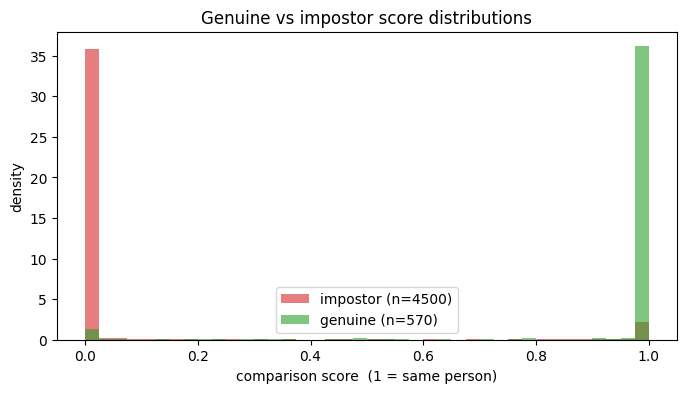

In [28]:
plt.figure(figsize=(8, 4))
bins = np.linspace(0, 1, 41)
plt.hist(impostor_scores, bins=bins, alpha=0.6, density=True, color='tab:red', label=f'impostor (n={impostor_scores.size})')
plt.hist(genuine_scores, bins=bins, alpha=0.6, density=True, color='tab:green', label=f'genuine (n={genuine_scores.size})')
plt.xlabel('comparison score  (1 = same person)')
plt.ylabel('density')
plt.title('Genuine vs impostor score distributions')
plt.legend()
plt.show()

## FMR / FNMR / DET / EER / d-prime (comparison level, matcher)
- FMR(t)  = impostor scores >= t  (impostors wrongly matched)
- FNMR(t) = genuine  scores <  t  (genuines wrongly rejected)

EER      = 0.070  at threshold 0.608
d-prime  = 3.672  (higher = better separated)


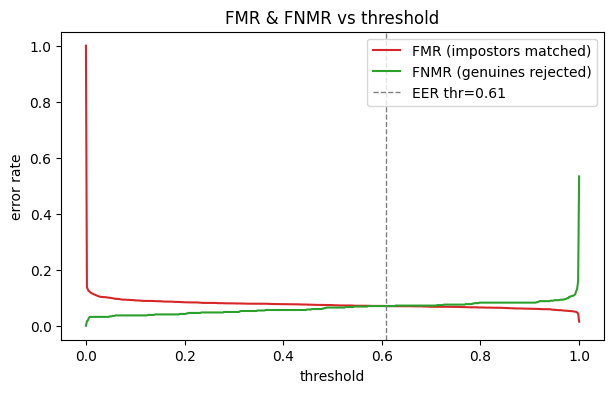

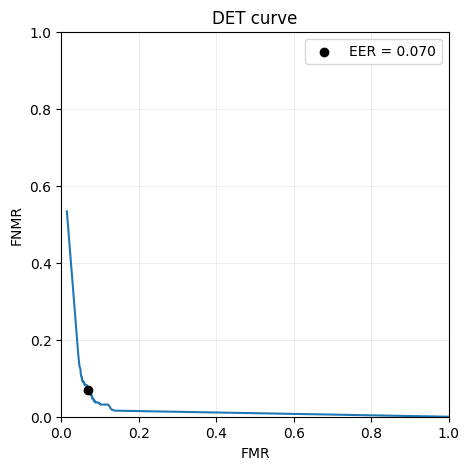

In [29]:
thresholds = np.linspace(0, 1, 501)
fmr = np.array([np.mean(impostor_scores >= t) for t in thresholds])
fnmr = np.array([np.mean(genuine_scores < t) for t in thresholds])
i = np.argmin(np.abs(fmr - fnmr))                 # EER: FMR ~= FNMR
eer, eer_thr = (fmr[i] + fnmr[i]) / 2, thresholds[i]
dprime = (genuine_scores.mean() - impostor_scores.mean()) / np.sqrt((genuine_scores.var() + impostor_scores.var()) / 2)
print(f'EER      = {eer:.3f}  at threshold {eer_thr:.3f}')
print(f"d-prime  = {dprime:.3f}  (higher = better separated)")

# FMR & FNMR vs threshold
plt.figure(figsize=(7, 4))
plt.plot(thresholds, fmr, color='tab:red', label='FMR (impostors matched)')
plt.plot(thresholds, fnmr, color='tab:green', label='FNMR (genuines rejected)')
plt.axvline(eer_thr, ls='--', color='gray', lw=1, label=f'EER thr={eer_thr:.2f}')
plt.xlabel('threshold'); plt.ylabel('error rate')
plt.title('FMR & FNMR vs threshold'); plt.legend(); plt.show()

# DET curve: FNMR vs FMR, TODO maybe log axis?
plt.figure(figsize=(5, 5))
plt.plot(fmr, fnmr, color='tab:blue')
plt.scatter([eer], [eer], color='k', zorder=5, label=f'EER = {eer:.3f}')
plt.xlabel('FMR'); plt.ylabel('FNMR'); plt.title('DET curve')
plt.xlim(0, 1); plt.ylim(0, 1); plt.grid(alpha=0.3); plt.legend(); plt.show()

## FAR / FRR (Transaction level, decider)

In [30]:
imp_dec = np.array(impostor_decisions)
far = imp_dec.mean() if imp_dec.size else float('nan')
print(f'operating point: MATCH_THR={MATCH_THR}, DECISION_THR={DECISION_THR}')
print(f'FAR (transaction) = {far:.3f}   ({imp_dec.sum()}/{imp_dec.size} impostors accepted)')

gen_dec = np.array(genuine_decisions)
frr = 1 - gen_dec.mean()
print(f'FRR (transaction) = {frr:.3f}   ({(~gen_dec).sum()}/{gen_dec.size} genuines rejected)')

operating point: MATCH_THR=0.979, DECISION_THR=0.6
FAR (transaction) = 0.047   (14/300 impostors accepted)
FRR (transaction) = 0.132   (5/38 genuines rejected)


## Inference latency

How long one verification transaction takes (responsiveness/throughput).
- The first call traces the TF graph, and CPU scheduling / thermal throttling jitter the rest. So: warm up, then repeat

In [31]:
# Inference latency (direct model call; no predict() Python/callback overhead)
import time

def bench(fn, n=100, warmup=10):
    """Warm up (discard graph tracing / first-call cost), then time n repeats -> ms array."""
    for _ in range(warmup):
        fn()
    t = np.empty(n)
    for k in range(n):
        t0 = time.perf_counter()
        fn()
        t[k] = (time.perf_counter() - t0) * 1e3   # ms
    return t

def summarize(name, t):
    print(f'{name:22s} median={np.median(t):6.2f}  mean={t.mean():6.2f}  'f'p95={np.percentile(t,95):6.2f}  min={t.min():6.2f}  std={t.std():5.2f} ms  (n={t.size})')

R = ref_batch.shape[0]
probe_all = tf.repeat(tf.expand_dims(preprocess(gen_paths[0]), 0), R, axis=0)  # 1 probe vs all refs
one_a = tf.expand_dims(preprocess(gen_paths[0]), 0)
one_b = ref_batch[:1]

t_pair = bench(lambda: model([one_a, one_b], training=False))         # single 1:1 comparison
t_full = bench(lambda: model([probe_all, ref_batch], training=False)) # full transaction (1 probe vs all refs)

print(f'device: {"GPU" if tf.config.get_visible_devices("GPU") else "CPU"}')
summarize('1:1 comparison', t_pair)
summarize(f'full transaction (R={R})', t_full)
print(f'per-reference marginal ~ {t_full.mean()/R:.2f} ms   throughput ~ {1000*R/t_full.mean():.0f} pairs/s')

# latency vs gallery size (more reference images -> slower decision, ~linear)
print('\nlatency vs number of reference images:')
for r in sorted({1, 5, 10, 25, R}):
    if r > R:
        continue
    pr = tf.repeat(tf.expand_dims(preprocess(gen_paths[0]), 0), r, axis=0)
    tr = bench(lambda pr=pr, r=r: model([pr, ref_batch[:r]], training=False), n=50)
    print(f'  R={r:3d}  median={np.median(tr):6.2f} ms')


device: GPU
1:1 comparison         median=  7.26  mean=  7.02  p95=  8.06  min=  5.59  std= 0.89 ms  (n=100)
full transaction (R=15) median= 23.63  mean= 23.18  p95= 24.71  min=  7.86  std= 2.79 ms  (n=100)
per-reference marginal ~ 1.55 ms   throughput ~ 647 pairs/s

latency vs number of reference images:
  R=  1  median=  5.79 ms
  R=  5  median=  8.78 ms
  R= 10  median= 16.60 ms
  R= 15  median= 23.37 ms


### Interpretation